# 01 — Exploratory Data Analysis (EDA)
**Owner:** Mariam — Member 1: Data Engineering & SQL Lead
**Dataset:** UCI Online Retail II

This notebook covers:
1. Setup & loading the raw dataset
2. Data quality checks (missingness, duplicates, types)
3. Univariate & target-focused visual analysis (Quantity, Price, Country, Revenue)
4. Cleaning rules + applying them
5. Building the SQL data warehouse (SQLite)
6. Running 12 analytical SQL queries (JOINs, CTEs, Window Functions)
7. Summary of key findings


In [1]:
!mkdir -p src/data
!mkdir -p sql
!mkdir -p data
!mkdir -p reports
!mkdir -p tests
!touch src/__init__.py
!touch src/data/__init__.py
print("Folders created ✅")

Folders created ✅


In [2]:
%%writefile src/data/loader.py

from __future__ import annotations

import sqlite3
import urllib.request
from pathlib import Path
import pandas as pd


RAW_DATA_URL = "https://archive.ics.uci.edu/static/public/502/online+retail+ii.zip"


RAW_COLUMNS = [
    "Invoice",
    "StockCode",
    "Description",
    "Quantity",
    "InvoiceDate",
    "Price",
    "Customer ID",
    "Country",
]


def download_raw_data(dest_dir: str = "data/raw") -> Path:
    """Download and unzip the Online Retail II dataset from UCI."""

    dest = Path(dest_dir)
    dest.mkdir(parents=True, exist_ok=True)

    zip_path = dest / "online_retail_ii.zip"

    if not zip_path.exists():
        urllib.request.urlretrieve(RAW_DATA_URL, zip_path)

    import zipfile

    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(dest)

    xlsx_files = list(dest.glob("*.xlsx"))

    if not xlsx_files:
        raise FileNotFoundError(
            f"No .xlsx file found after extracting {zip_path}"
        )

    return xlsx_files[0]


def load_raw_data(path: str) -> pd.DataFrame:
    """Load and merge both sheets of the Online Retail II workbook."""

    df_2009 = pd.read_excel(
        path,
        sheet_name="Year 2009-2010"
    )

    df_2010 = pd.read_excel(
        path,
        sheet_name="Year 2010-2011"
    )

    df = pd.concat(
        [df_2009, df_2010],
        ignore_index=True
    )

    return df


def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """Apply the project's cleaning rules to the raw transactions."""

    df = df.copy()

    # Remove duplicate rows
    df = df.drop_duplicates()

    # Convert Invoice to string
    df["Invoice"] = df["Invoice"].astype(str)

    # Identify cancelled invoices
    df["IsCancelled"] = df["Invoice"].str.startswith("C")

    # Remove transactions without Customer ID
    df = df.dropna(subset=["Customer ID"])

    # Convert Customer ID to integer
    df["Customer ID"] = df["Customer ID"].astype(int)

    # Keep valid prices and non-zero quantities
    valid_price = df["Price"] > 0
    valid_qty = df["Quantity"] != 0

    df = df[valid_price & valid_qty]

    # Calculate revenue
    df["Revenue"] = df["Quantity"] * df["Price"]

    # Convert date column
    df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

    return df.reset_index(drop=True)


def validate_data(df: pd.DataFrame) -> None:
    """Run basic sanity checks on the cleaned dataframe."""

    required_cols = {
        "Invoice",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "Price",
        "Customer ID",
        "Country",
        "Revenue",
        "IsCancelled",
    }

    missing = required_cols - set(df.columns)

    assert not missing, f"Missing expected columns: {missing}"

    assert df["Customer ID"].isnull().sum() == 0, \
        "Found null Customer ID after cleaning"

    assert df["Price"].min() > 0, \
        "Found non-positive Price after cleaning"

    assert df["Quantity"].apply(lambda x: x != 0).all(), \
        "Found zero Quantity rows"

    assert df["InvoiceDate"].dtype.kind == "M", \
        "InvoiceDate must be a datetime column"


def build_sqlite_db(
    df: pd.DataFrame,
    schema_path: str,
    db_path: str = "retail.db"
) -> None:
    """Load a cleaned dataframe into a SQLite database."""

    conn = sqlite3.connect(db_path)

    with open(schema_path, "r", encoding="utf-8") as f:
        conn.executescript(f.read())

    # Customers
    customers = (
        df[["Customer ID", "Country"]]
        .drop_duplicates(subset=["Customer ID"])
        .rename(
            columns={
                "Customer ID": "customer_id",
                "Country": "country",
            }
        )
    )

    customers.to_sql(
        "customers",
        conn,
        if_exists="append",
        index=False,
    )

    # Products
    products = (
        df[["StockCode", "Description"]]
        .drop_duplicates(subset=["StockCode"])
        .rename(
            columns={
                "StockCode": "stock_code",
                "Description": "description",
            }
        )
    )

    products.to_sql(
        "products",
        conn,
        if_exists="append",
        index=False,
    )

    # Orders
    orders = (
        df[
            [
                "Invoice",
                "Customer ID",
                "InvoiceDate",
                "IsCancelled",
            ]
        ]
        .drop_duplicates(subset=["Invoice"])
        .rename(
            columns={
                "Invoice": "invoice_no",
                "Customer ID": "customer_id",
                "InvoiceDate": "invoice_date",
                "IsCancelled": "is_cancelled",
            }
        )
    )

    orders["is_cancelled"] = orders["is_cancelled"].astype(int)

    orders.to_sql(
        "orders",
        conn,
        if_exists="append",
        index=False,
    )

    # Order items
    items = (
        df[
            [
                "Invoice",
                "StockCode",
                "Quantity",
                "Price",
                "Revenue",
            ]
        ]
        .rename(
            columns={
                "Invoice": "invoice_no",
                "StockCode": "stock_code",
                "Quantity": "quantity",
                "Price": "unit_price",
                "Revenue": "revenue",
            }
        )
    )

    items.to_sql(
        "order_items",
        conn,
        if_exists="append",
        index=False,
    )

    conn.commit()
    conn.close()


if __name__ == "__main__":

    xlsx_path = download_raw_data()

    raw_df = load_raw_data(str(xlsx_path))

    clean_df = clean_data(raw_df)

    validate_data(clean_df)

    build_sqlite_db(
        clean_df,
        schema_path="sql/schema.sql",
        db_path="retail.db",
    )

    print(
        f"Loaded {len(clean_df):,} "
        f"clean transactions into retail.db"
    )

Writing src/data/loader.py


In [3]:
import pandas as pd

In [4]:
!cat src/data/loader.py


from __future__ import annotations

import sqlite3
import urllib.request
from pathlib import Path
import pandas as pd


RAW_DATA_URL = "https://archive.ics.uci.edu/static/public/502/online+retail+ii.zip"


RAW_COLUMNS = [
    "Invoice",
    "StockCode",
    "Description",
    "Quantity",
    "InvoiceDate",
    "Price",
    "Customer ID",
    "Country",
]


def download_raw_data(dest_dir: str = "data/raw") -> Path:
    """Download and unzip the Online Retail II dataset from UCI."""

    dest = Path(dest_dir)
    dest.mkdir(parents=True, exist_ok=True)

    zip_path = dest / "online_retail_ii.zip"

    if not zip_path.exists():
        urllib.request.urlretrieve(RAW_DATA_URL, zip_path)

    import zipfile

    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(dest)

    xlsx_files = list(dest.glob("*.xlsx"))

    if not xlsx_files:
        raise FileNotFoundError(
            f"No .xlsx file found after extracting {zip_path}"
        )

    return xlsx_files[0]


def load

In [5]:
import importlib
import src.data.loader

importlib.reload(src.data.loader)

<module 'src.data.loader' from '/content/src/data/loader.py'>

In [6]:
dir(src.data.loader)

['Path',
 'RAW_COLUMNS',
 'RAW_DATA_URL',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'annotations',
 'build_sqlite_db',
 'clean_data',
 'download_raw_data',
 'load_raw_data',
 'pd',
 'sqlite3',
 'urllib',
 'validate_data']

In [7]:
from src.data.loader import (
    download_raw_data,
    load_raw_data,
    clean_data,
    validate_data,
)

## 1. Load the raw data

In [8]:
xlsx_path = download_raw_data()

print(xlsx_path)

data/raw/online_retail_II.xlsx


In [10]:
raw_df = load_raw_data(str(xlsx_path))

print(raw_df.shape)
raw_df.head()

(1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [11]:
raw_df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France


## 2. Data quality checks

In [12]:
print("Rows:", raw_df.shape[0])
print("Columns:", raw_df.shape[1])
print("Shape:", raw_df.shape)

Rows: 1067371
Columns: 8
Shape: (1067371, 8)


In [13]:
print("Columns:")
for col in raw_df.columns:
    print("-", col)

Columns:
- Invoice
- StockCode
- Description
- Quantity
- InvoiceDate
- Price
- Customer ID
- Country


In [14]:
print("Data types:")
display(raw_df.dtypes.to_frame("dtype"))

Data types:


,dtype
Invoice,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
Price,float64
Customer ID,float64
Country,object


In [15]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [16]:
missing_summary = pd.DataFrame({
    "missing_count": raw_df.isnull().sum(),
    "missing_percentage": (
        raw_df.isnull().mean() * 100
    ).round(2)
})

display(missing_summary)

,missing_count,missing_percentage
Invoice,0,0.00
StockCode,0,0.00
Description,4382,0.41
Quantity,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
Customer ID,243007,22.77
Country,0,0.00


In [17]:
duplicate_count = raw_df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 34335


In [18]:
duplicates = raw_df[raw_df.duplicated(keep=False)]

display(duplicates.head(10))

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
367,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom


In [19]:
cancelled_mask = raw_df["Invoice"].astype(str).str.startswith("C")

print("Cancelled transactions:", cancelled_mask.sum())

Cancelled transactions: 19494


In [20]:
display(raw_df[cancelled_mask].head(5))

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


In [21]:
print("Minimum Quantity:", raw_df["Quantity"].min())
print("Maximum Quantity:", raw_df["Quantity"].max())
print("Zero Quantity:", (raw_df["Quantity"] == 0).sum())
print("Negative Quantity:", (raw_df["Quantity"] < 0).sum())

Minimum Quantity: -80995
Maximum Quantity: 80995
Zero Quantity: 0
Negative Quantity: 22950


In [22]:
display(
    raw_df[raw_df["Quantity"] < 0].head(10)
)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom


In [23]:
print("Minimum Price:", raw_df["Price"].min())
print("Maximum Price:", raw_df["Price"].max())
print("Zero Price:", (raw_df["Price"] == 0).sum())
print("Negative Price:", (raw_df["Price"] < 0).sum())

Minimum Price: -53594.36
Maximum Price: 38970.0
Zero Price: 6202
Negative Price: 5


In [24]:
display(
    raw_df[raw_df["Price"] <= 0].head(10)
)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.0,NaN,United Kingdom
3162,489660,35956,lost,-1043,2009-12-01 17:43:00,0.0,NaN,United Kingdom
3168,489663,35605A,damages,-117,2009-12-01 18:02:00,0.0,NaN,United Kingdom
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.0,NaN,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0,NaN,United Kingdom


In [25]:
print(
    "Missing descriptions:",
    raw_df["Description"].isnull().sum()
)

Missing descriptions: 4382


In [26]:
display(
    raw_df[raw_df["Description"].isnull()].head(5)
)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.0,NaN,United Kingdom
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.0,NaN,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0,NaN,United Kingdom


In [27]:
print(
    "Unique customers:",
    raw_df["Customer ID"].nunique()
)

Unique customers: 5942


In [28]:
print(
    "Missing Customer IDs:",
    raw_df["Customer ID"].isnull().sum()
)

Missing Customer IDs: 243007


In [29]:
print(
    "Number of countries:",
    raw_df["Country"].nunique()
)

Number of countries: 43


In [30]:
raw_df["Country"].value_counts().head(10)

,count
Country,
United Kingdom,981330
EIRE,17866
Germany,17624
France,14330
Netherlands,5140
Spain,3811
Switzerland,3189
Belgium,3123
Portugal,2620


In [31]:
print(
    "Unique products:",
    raw_df["StockCode"].nunique()
)

Unique products: 5305


In [32]:
print("First date:")
print(raw_df["InvoiceDate"].min())

print("\nLast date:")
print(raw_df["InvoiceDate"].max())

First date:
2009-12-01 07:45:00

Last date:
2011-12-09 12:50:00


In [33]:
dates = pd.to_datetime(raw_df["InvoiceDate"], errors="coerce")

print("First date:", dates.min())
print("Last date:", dates.max())

First date: 2009-12-01 07:45:00
Last date: 2011-12-09 12:50:00


In [34]:
raw_df[["Quantity", "Price"]].describe()

,Quantity,Price
count,1.067371e+06,1.067371e+06
mean,9.938898e+00,4.649388e+00
std,1.727058e+02,1.235531e+02
min,-8.099500e+04,-5.359436e+04
25%,1.000000e+00,1.250000e+00
50%,3.000000e+00,2.100000e+00
75%,1.000000e+01,4.150000e+00
max,8.099500e+04,3.897000e+04


## 3. Univariate & target-focused visual analysis

The checks above are numeric; this section adds the visual univariate analysis
(distributions, top countries) and the target-focused analysis (Revenue,
cancellations) required for a complete EDA.


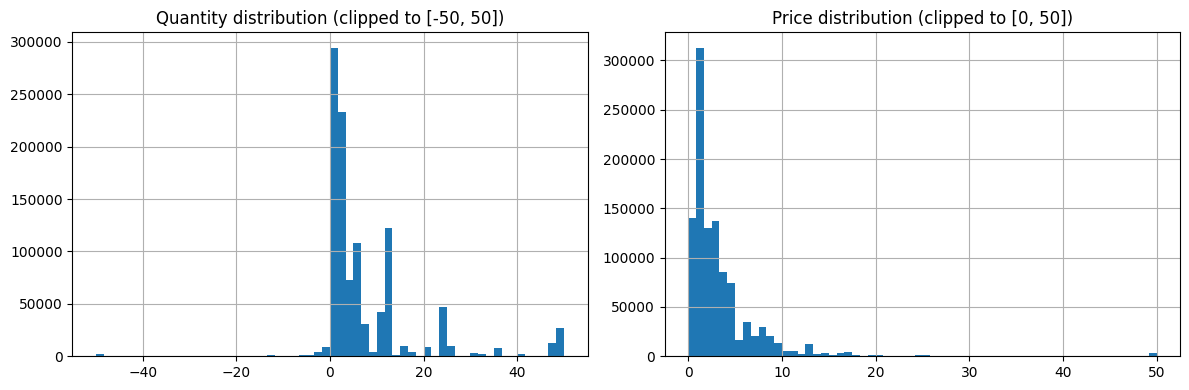

In [35]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
raw_df['Quantity'].clip(-50, 50).hist(bins=60, ax=axes[0])
axes[0].set_title('Quantity distribution (clipped to [-50, 50])')

raw_df['Price'].clip(0, 50).hist(bins=60, ax=axes[1])
axes[1].set_title('Price distribution (clipped to [0, 50])')
plt.tight_layout()
plt.show()


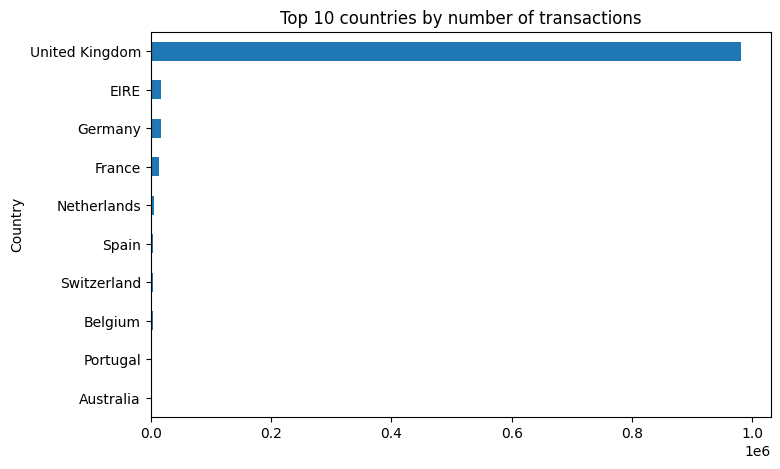

In [36]:
top_countries = raw_df['Country'].value_counts().head(10)
top_countries.plot(kind='barh', figsize=(8, 5), title='Top 10 countries by number of transactions')
plt.gca().invert_yaxis()
plt.show()


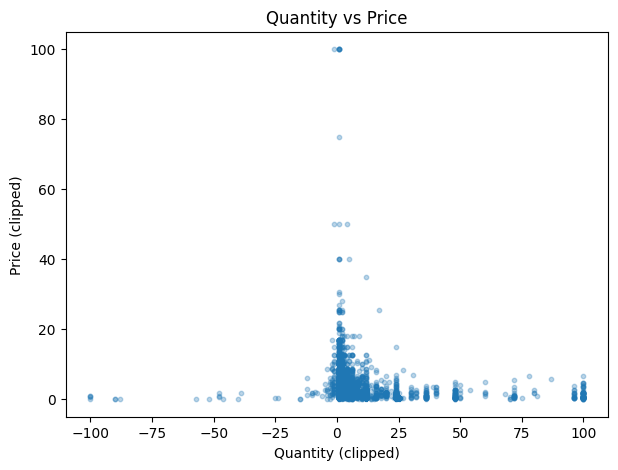

In [37]:
# Quantity vs Price relationship (bivariate)
sample = raw_df.sample(min(5000, len(raw_df)), random_state=42)
plt.figure(figsize=(7, 5))
plt.scatter(sample['Quantity'].clip(-100, 100), sample['Price'].clip(0, 100), alpha=0.3, s=10)
plt.xlabel('Quantity (clipped)')
plt.ylabel('Price (clipped)')
plt.title('Quantity vs Price')
plt.show()


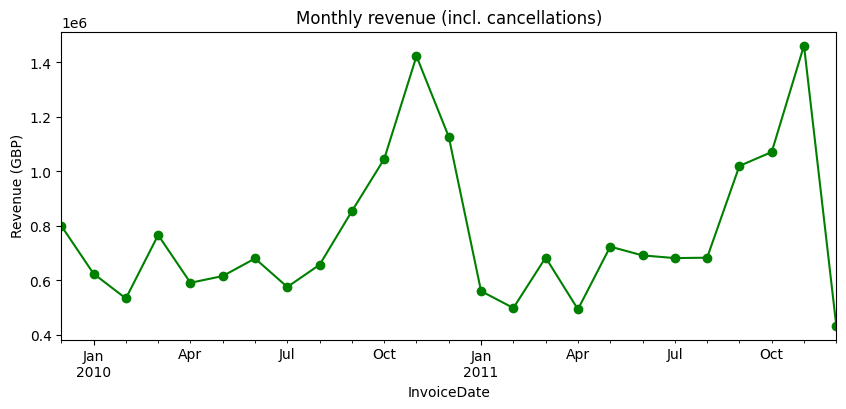

In [38]:
# Target-focused analysis: Revenue
raw_df['Revenue'] = raw_df['Quantity'] * raw_df['Price']

monthly_revenue = raw_df.set_index('InvoiceDate').resample('ME')['Revenue'].sum()
monthly_revenue.plot(figsize=(10, 4), marker='o', color='green', title='Monthly revenue (incl. cancellations)')
plt.ylabel('Revenue (GBP)')
plt.show()


In [39]:
is_cancel = raw_df['Invoice'].astype(str).str.startswith('C')
print("Revenue lost to cancellations (GBP):", round(raw_df.loc[is_cancel, 'Revenue'].sum(), 2))
print("Net revenue (excl. cancellations):", round(raw_df.loc[~is_cancel, 'Revenue'].sum(), 2))


Revenue lost to cancellations (GBP): -1526667.86
Net revenue (excl. cancellations): 20813918.43


### 3.1 Additional visual analysis

A few more views that help spot outliers and behavioural patterns before cleaning.


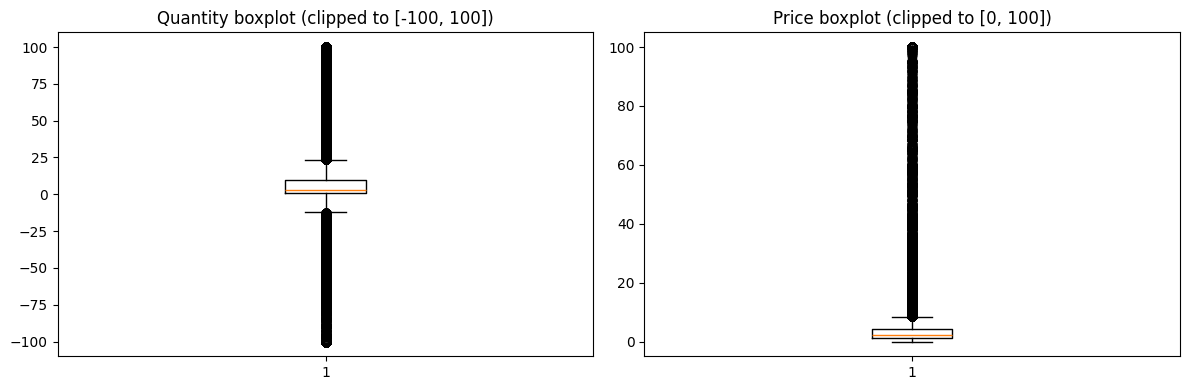

In [40]:
# 1. Boxplots for outlier detection
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(raw_df['Quantity'].clip(-100, 100), vert=True)
axes[0].set_title('Quantity boxplot (clipped to [-100, 100])')
axes[1].boxplot(raw_df['Price'].clip(0, 100), vert=True)
axes[1].set_title('Price boxplot (clipped to [0, 100])')
plt.tight_layout()
plt.show()


In [42]:
# 2. Cancellation rate trend over time
raw_df['IsCancelled'] = raw_df['Invoice'].astype(str).str.startswith('C')

print("Revenue lost to cancellations (GBP):", round(raw_df.loc[raw_df['IsCancelled'], 'Revenue'].sum(), 2))
print("Net revenue (excl. cancellations):", round(raw_df.loc[~raw_df['IsCancelled'], 'Revenue'].sum(), 2))


Revenue lost to cancellations (GBP): -1526667.86
Net revenue (excl. cancellations): 20813918.43


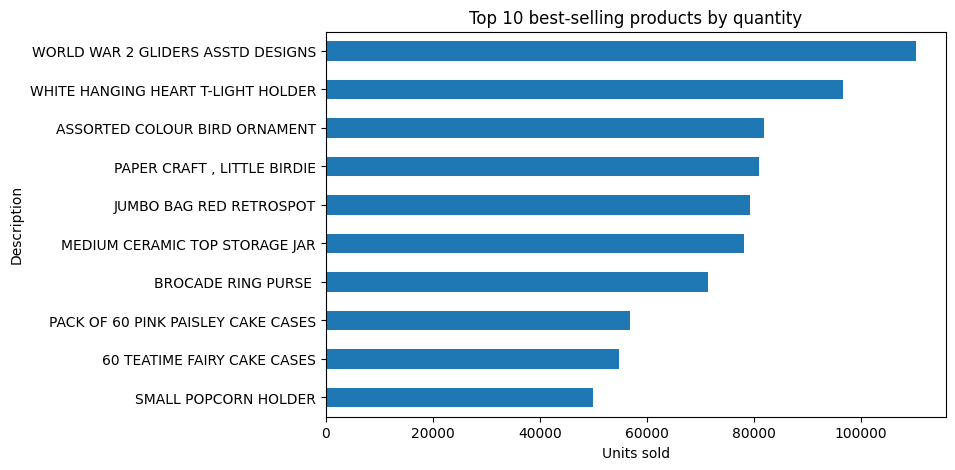

In [43]:
# 3. Top 10 best-selling products by quantity (excluding cancellations)
top_products = (
    raw_df[~raw_df['IsCancelled']]
    .groupby('Description')['Quantity'].sum()
    .sort_values(ascending=False)
    .head(10)
)
top_products.plot(kind='barh', figsize=(8, 5), title='Top 10 best-selling products by quantity')
plt.gca().invert_yaxis()
plt.xlabel('Units sold')
plt.show()


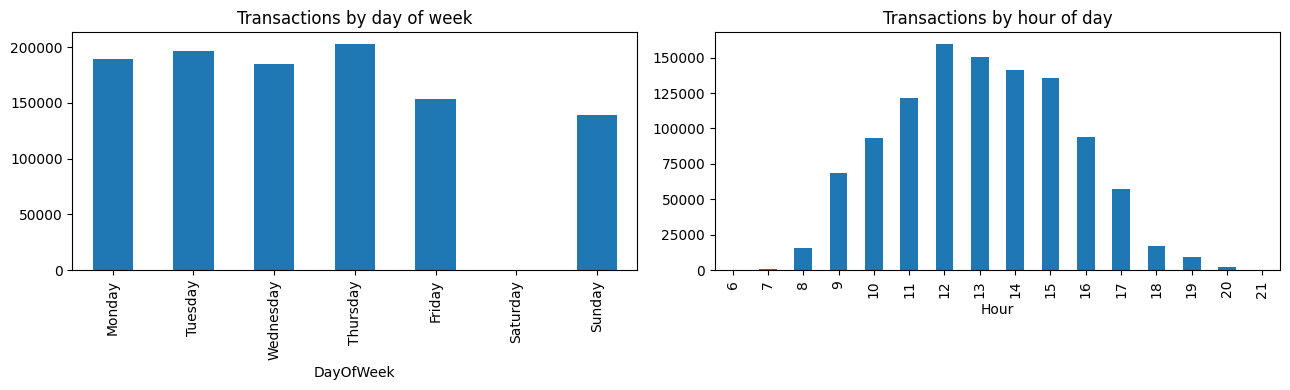

In [44]:
# 4. Purchase patterns by day of week and hour
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
raw_df['DayOfWeek'] = raw_df['InvoiceDate'].dt.day_name()
raw_df['DayOfWeek'].value_counts().reindex(day_order).plot(
    kind='bar', ax=axes[0], title='Transactions by day of week'
)

raw_df['Hour'] = raw_df['InvoiceDate'].dt.hour
raw_df['Hour'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], title='Transactions by hour of day'
)

plt.tight_layout()
plt.show()


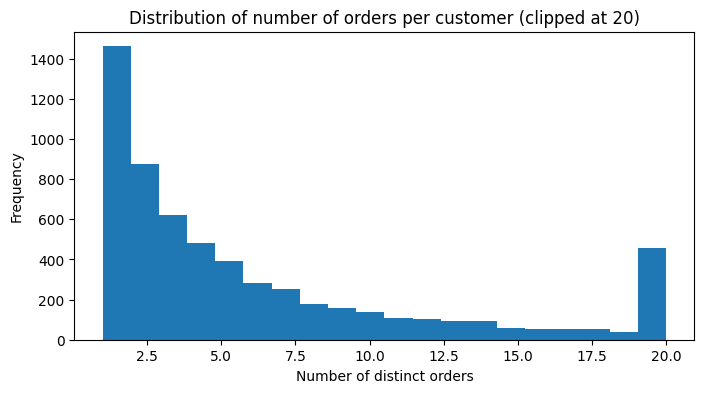

Median orders per customer: 4
Customers with only 1 order: 1,461 (24.6%)


In [45]:
# 5. Distribution of number of orders per customer
orders_per_customer = (
    raw_df.dropna(subset=['Customer ID'])
    .groupby('Customer ID')['Invoice'].nunique()
)
orders_per_customer.clip(upper=20).plot(
    kind='hist', bins=20, figsize=(8, 4),
    title='Distribution of number of orders per customer (clipped at 20)'
)
plt.xlabel('Number of distinct orders')
plt.show()

print(f"Median orders per customer: {orders_per_customer.median():.0f}")
print(f"Customers with only 1 order: {(orders_per_customer == 1).sum():,} "
      f"({(orders_per_customer == 1).mean()*100:.1f}%)")


## 4. Cleaning rules applied

Based on the checks above, the following rules are applied inside `src/data/loader.py::clean_data`:

1. Drop rows with missing `Customer ID` (~22.8% of rows) — needed for customer-level analysis.
2. Drop exact duplicate rows (34,335 rows).
3. Drop rows with `Price <= 0` or `Quantity == 0` (invalid records).
4. Keep cancellations but flag them via `IsCancelled`, instead of deleting them — needed for cancellation-rate KPIs.
5. Add a `Revenue` column (`Quantity * Price`).


In [46]:
clean_df = clean_data(raw_df)

In [47]:
comparison = pd.DataFrame({
    "Raw Data": [len(raw_df)],
    "Clean Data": [len(clean_df)],
    "Removed Rows": [len(raw_df) - len(clean_df)]
})

display(comparison)

,Raw Data,Clean Data,Removed Rows
0,1067371,797815,269556


In [48]:
clean_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,IsCancelled,DayOfWeek,Hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,False,Tuesday,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,False,Tuesday,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,False,Tuesday,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,False,Tuesday,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,False,Tuesday,7


In [49]:
clean_df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,IsCancelled,DayOfWeek,Hour
797810,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60,False,Friday,12
797811,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60,False,Friday,12
797812,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60,False,Friday,12
797813,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680,France,14.85,False,Friday,12
797814,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680,France,18.00,False,Friday,12


In [50]:
clean_df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
Price,0
Customer ID,0
Country,0
Revenue,0
IsCancelled,0


In [51]:
print(
    "Duplicates after cleaning:",
    clean_df.duplicated().sum()
)

Duplicates after cleaning: 0


In [52]:
validate_data(clean_df)

print("✅ Clean data passed validation.")

✅ Clean data passed validation.


## 5. SQL data warehouse: schema + ETL into SQLite

In [53]:
%%writefile sql/schema.sql
-- ============================================================
-- Enterprise AI Data Analyst — SQL Schema
-- Member 1: Data Engineering & SQL Lead
-- Source dataset: UCI Online Retail II
-- Engine: SQLite (portable, works directly inside Colab)
-- ============================================================

DROP TABLE IF EXISTS order_items;
DROP TABLE IF EXISTS orders;
DROP TABLE IF EXISTS products;
DROP TABLE IF EXISTS customers;

-- Dimension: customers
CREATE TABLE customers (
    customer_id INTEGER PRIMARY KEY,
    country     TEXT NOT NULL
);

-- Dimension: products
CREATE TABLE products (
    stock_code  TEXT PRIMARY KEY,
    description TEXT
);

-- Fact/header: orders (one row per invoice)
CREATE TABLE orders (
    invoice_no    TEXT PRIMARY KEY,
    customer_id   INTEGER,
    invoice_date  DATETIME NOT NULL,
    is_cancelled  INTEGER NOT NULL DEFAULT 0,
    FOREIGN KEY (customer_id) REFERENCES customers(customer_id)
);

-- Fact/detail: order line items
CREATE TABLE order_items (
    item_id     INTEGER PRIMARY KEY AUTOINCREMENT,
    invoice_no  TEXT NOT NULL,
    stock_code  TEXT NOT NULL,
    quantity    INTEGER NOT NULL,
    unit_price  REAL NOT NULL,
    revenue     REAL NOT NULL,
    FOREIGN KEY (invoice_no) REFERENCES orders(invoice_no),
    FOREIGN KEY (stock_code) REFERENCES products(stock_code)
);

CREATE INDEX idx_orders_customer   ON orders(customer_id);
CREATE INDEX idx_orders_date       ON orders(invoice_date);
CREATE INDEX idx_items_invoice     ON order_items(invoice_no);
CREATE INDEX idx_items_stockcode   ON order_items(stock_code);

Writing sql/schema.sql


In [54]:
%%writefile sql/analytical_queries.sql
-- ============================================================
-- Enterprise AI Data Analyst — Analytical SQL Queries (12)
-- Member 1: Data Engineering & SQL Lead
-- Uses: JOIN, CTE, Window Functions, Aggregation
-- ============================================================

-- 1. Top 10 customers by total spend (JOIN + GROUP BY)
SELECT
    o.customer_id,
    c.country,
    ROUND(SUM(oi.revenue), 2) AS total_spent
FROM order_items oi
JOIN orders o    ON oi.invoice_no = o.invoice_no
JOIN customers c ON o.customer_id = c.customer_id
WHERE o.is_cancelled = 0
GROUP BY o.customer_id, c.country
ORDER BY total_spent DESC
LIMIT 10;


-- 2. Monthly revenue trend
SELECT
    strftime('%Y-%m', o.invoice_date) AS year_month,
    ROUND(SUM(oi.revenue), 2)         AS monthly_revenue
FROM order_items oi
JOIN orders o ON oi.invoice_no = o.invoice_no
WHERE o.is_cancelled = 0
GROUP BY year_month
ORDER BY year_month;


-- 3. Running (cumulative) revenue total over time — WINDOW FUNCTION
WITH monthly AS (
    SELECT
        strftime('%Y-%m', o.invoice_date) AS year_month,
        SUM(oi.revenue)                   AS monthly_revenue
    FROM order_items oi
    JOIN orders o ON oi.invoice_no = o.invoice_no
    WHERE o.is_cancelled = 0
    GROUP BY year_month
)
SELECT
    year_month,
    ROUND(monthly_revenue, 2) AS monthly_revenue,
    ROUND(SUM(monthly_revenue) OVER (ORDER BY year_month), 2) AS running_total
FROM monthly
ORDER BY year_month;


-- 4. Rank customers by spend within each country — WINDOW FUNCTION (PARTITION BY)
WITH customer_spend AS (
    SELECT
        c.country,
        o.customer_id,
        SUM(oi.revenue) AS total_spent
    FROM order_items oi
    JOIN orders o    ON oi.invoice_no = o.invoice_no
    JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.is_cancelled = 0
    GROUP BY c.country, o.customer_id
)
SELECT
    country,
    customer_id,
    ROUND(total_spent, 2) AS total_spent,
    RANK() OVER (PARTITION BY country ORDER BY total_spent DESC) AS rank_in_country
FROM customer_spend
ORDER BY country, rank_in_country;


-- 5. First purchase date per customer (CTE) + customer lifetime in days
WITH first_purchase AS (
    SELECT
        customer_id,
        MIN(invoice_date) AS first_order_date,
        MAX(invoice_date) AS last_order_date
    FROM orders
    WHERE is_cancelled = 0
    GROUP BY customer_id
)
SELECT
    customer_id,
    first_order_date,
    last_order_date,
    CAST(julianday(last_order_date) - julianday(first_order_date) AS INTEGER) AS lifetime_days
FROM first_purchase
ORDER BY lifetime_days DESC
LIMIT 20;


-- 6. Top 10 best-selling products by quantity
SELECT
    p.stock_code,
    p.description,
    SUM(oi.quantity) AS total_units_sold
FROM order_items oi
JOIN products p ON oi.stock_code = p.stock_code
JOIN orders o   ON oi.invoice_no = o.invoice_no
WHERE o.is_cancelled = 0
GROUP BY p.stock_code, p.description
ORDER BY total_units_sold DESC
LIMIT 10;


-- 7. Cancellation rate per month
SELECT
    strftime('%Y-%m', invoice_date) AS year_month,
    COUNT(*)                                          AS total_orders,
    SUM(is_cancelled)                                  AS cancelled_orders,
    ROUND(100.0 * SUM(is_cancelled) / COUNT(*), 2)     AS cancellation_rate_pct
FROM orders
GROUP BY year_month
ORDER BY year_month;


-- 8. Average order value (AOV) per country
WITH order_totals AS (
    SELECT
        o.invoice_no,
        o.customer_id,
        SUM(oi.revenue) AS order_value
    FROM order_items oi
    JOIN orders o ON oi.invoice_no = o.invoice_no
    WHERE o.is_cancelled = 0
    GROUP BY o.invoice_no, o.customer_id
)
SELECT
    c.country,
    ROUND(AVG(ot.order_value), 2) AS avg_order_value,
    COUNT(ot.invoice_no)          AS num_orders
FROM order_totals ot
JOIN customers c ON ot.customer_id = c.customer_id
GROUP BY c.country
ORDER BY avg_order_value DESC;


-- 9. One-time buyers (bought exactly once) — simple churn/loyalty indicator
WITH order_counts AS (
    SELECT customer_id, COUNT(DISTINCT invoice_no) AS num_orders
    FROM orders
    WHERE is_cancelled = 0
    GROUP BY customer_id
)
SELECT
    COUNT(*) AS one_time_buyers,
    (SELECT COUNT(*) FROM order_counts) AS total_customers,
    ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM order_counts), 2) AS pct_one_time_buyers
FROM order_counts
WHERE num_orders = 1;


-- 10. Month-over-month revenue growth % — WINDOW FUNCTION (LAG)
WITH monthly AS (
    SELECT
        strftime('%Y-%m', o.invoice_date) AS year_month,
        SUM(oi.revenue)                   AS monthly_revenue
    FROM order_items oi
    JOIN orders o ON oi.invoice_no = o.invoice_no
    WHERE o.is_cancelled = 0
    GROUP BY year_month
)
SELECT
    year_month,
    ROUND(monthly_revenue, 2) AS monthly_revenue,
    ROUND(monthly_revenue - LAG(monthly_revenue) OVER (ORDER BY year_month), 2) AS revenue_change,
    ROUND(
        100.0 * (monthly_revenue - LAG(monthly_revenue) OVER (ORDER BY year_month))
        / NULLIF(LAG(monthly_revenue) OVER (ORDER BY year_month), 0), 2
    ) AS mom_growth_pct
FROM monthly
ORDER BY year_month;


-- 11. Top 5 products per country by revenue — WINDOW FUNCTION (ROW_NUMBER + PARTITION)
WITH product_country_sales AS (
    SELECT
        c.country,
        p.stock_code,
        p.description,
        SUM(oi.revenue) AS revenue
    FROM order_items oi
    JOIN orders o    ON oi.invoice_no = o.invoice_no
    JOIN customers c ON o.customer_id = c.customer_id
    JOIN products p  ON oi.stock_code = p.stock_code
    WHERE o.is_cancelled = 0
    GROUP BY c.country, p.stock_code, p.description
),
ranked AS (
    SELECT
        *,
        ROW_NUMBER() OVER (PARTITION BY country ORDER BY revenue DESC) AS rn
    FROM product_country_sales
)
SELECT country, stock_code, description, ROUND(revenue, 2) AS revenue
FROM ranked
WHERE rn <= 5
ORDER BY country, rn;


-- 12. Customer segments by spend quartile — WINDOW FUNCTION (NTILE)
WITH customer_spend AS (
    SELECT
        o.customer_id,
        SUM(oi.revenue) AS total_spent
    FROM order_items oi
    JOIN orders o ON oi.invoice_no = o.invoice_no
    WHERE o.is_cancelled = 0
    GROUP BY o.customer_id
)
SELECT
    customer_id,
    ROUND(total_spent, 2) AS total_spent,
    NTILE(4) OVER (ORDER BY total_spent DESC) AS spend_quartile
FROM customer_spend
ORDER BY total_spent DESC;

Writing sql/analytical_queries.sql


In [55]:
!echo "---- src/data ----" && ls -la src/data
!echo "---- sql ----" && ls -la sql
!echo "---- Preview loader.py ----" && head -20 src/data/loader.py

---- src/data ----
total 20
drwxr-xr-x 3 root root 4096 Sep 14 13:06 .
drwxr-xr-x 4 root root 4096 Sep 14 13:06 ..
-rw-r--r-- 1 root root    0 Sep 14 13:06 __init__.py
-rw-r--r-- 1 root root 5889 Sep 14 13:06 loader.py
drwxr-xr-x 2 root root 4096 Sep 14 13:06 __pycache__
---- sql ----
total 20
drwxr-xr-x 2 root root 4096 Sep 14 13:15 .
drwxr-xr-x 1 root root 4096 Sep 14 13:06 ..
-rw-r--r-- 1 root root 6328 Sep 14 13:15 analytical_queries.sql
-rw-r--r-- 1 root root 1586 Sep 14 13:15 schema.sql
---- Preview loader.py ----

from __future__ import annotations

import sqlite3
import urllib.request
from pathlib import Path
import pandas as pd


RAW_DATA_URL = "https://archive.ics.uci.edu/static/public/502/online+retail+ii.zip"


RAW_COLUMNS = [
    "Invoice",
    "StockCode",
    "Description",
    "Quantity",
    "InvoiceDate",
    "Price",
    "Customer ID",


In [56]:
import sqlite3
from src.data.loader import build_sqlite_db

DB_PATH = "retail.db"
SCHEMA_PATH = "sql/schema.sql"

build_sqlite_db(clean_df, schema_path=SCHEMA_PATH, db_path=DB_PATH)
print("retail.db created ✅")

retail.db created ✅


In [57]:
conn = sqlite3.connect(DB_PATH)
for table in ["customers", "products", "orders", "order_items"]:
    count = pd.read_sql(f"SELECT COUNT(*) AS n FROM {table}", conn).iloc[0, 0]
    print(f"{table:12s}: {count:,} rows")

customers   : 5,939 rows
products    : 4,646 rows
orders      : 44,870 rows
order_items : 797,815 rows


In [58]:
orphan_invoices = pd.read_sql('''
    SELECT COUNT(*) AS n
    FROM order_items oi
    LEFT JOIN orders o ON oi.invoice_no = o.invoice_no
    WHERE o.invoice_no IS NULL
''', conn).iloc[0, 0]

orphan_products = pd.read_sql('''
    SELECT COUNT(*) AS n
    FROM order_items oi
    LEFT JOIN products p ON oi.stock_code = p.stock_code
    WHERE p.stock_code IS NULL
''', conn).iloc[0, 0]

print("Orphan order_items (no matching order):", orphan_invoices)
print("Orphan order_items (no matching product):", orphan_products)
assert orphan_invoices == 0 and orphan_products == 0, "Referential integrity check failed!"

Orphan order_items (no matching order): 0
Orphan order_items (no matching product): 0


## 6. Analytical SQL queries (12 queries: JOINs, CTEs, Window Functions)

In [59]:
import re

with open("sql/analytical_queries.sql", "r", encoding="utf-8") as f:
    lines = f.readlines()

queries = []
current = []
for line in lines:
    m = re.match(r"^-- (\d+)\. (.+)", line)
    if m:
        if current:
            queries.append("".join(current))
        current = []
    else:
        current.append(line)
if current:
    queries.append("".join(current))

queries = queries[1:]  # شيل الكومنت الأول (الهيدر)
print(f"Loaded {len(queries)} analytical queries")

Loaded 12 analytical queries


In [60]:
for i, q in enumerate(queries, start=1):
    try:
        df_result = pd.read_sql(q, conn)
        print(f"Query {i}: OK ✅ — {len(df_result)} rows")
    except Exception as e:
        print(f"Query {i}: FAILED ❌ -> {e}")

Query 1: OK ✅ — 10 rows
Query 2: OK ✅ — 25 rows
Query 3: OK ✅ — 25 rows
Query 4: OK ✅ — 5878 rows
Query 5: OK ✅ — 20 rows
Query 6: OK ✅ — 10 rows
Query 7: OK ✅ — 25 rows
Query 8: OK ✅ — 41 rows
Query 9: OK ✅ — 1 rows
Query 10: OK ✅ — 25 rows
Query 11: OK ✅ — 205 rows
Query 12: OK ✅ — 5878 rows


In [61]:
pd.read_sql(queries[0], conn)   # Query 1

,customer_id,country,total_spent
0,18102,United Kingdom,580987.04
1,14646,Netherlands,528602.52
2,14156,EIRE,313437.62
3,14911,EIRE,291420.81
4,17450,United Kingdom,244784.25
5,13694,United Kingdom,195640.69
6,17511,United Kingdom,172132.87
7,16446,United Kingdom,168472.50
8,16684,United Kingdom,147142.77
9,12415,Australia,144458.37


In [62]:
pd.read_sql(queries[9], conn)   # Query 10

,year_month,monthly_revenue,revenue_change,mom_growth_pct
0,2009-12,683504.01,NaN,NaN
1,2010-01,555802.67,-127701.34,-18.68
2,2010-02,504558.96,-51243.72,-9.22
3,2010-03,696978.47,192419.52,38.14
4,2010-04,591982.00,-104996.47,-15.06
5,2010-05,597833.38,5851.38,0.99
6,2010-06,636371.13,38537.75,6.45
7,2010-07,589736.17,-46634.96,-7.33
8,2010-08,602224.60,12488.43,2.12
9,2010-09,829013.95,226789.35,37.66


In [63]:
pd.read_sql(queries[3], conn)   # Query 4: rank customers by spend within each country


,country,customer_id,total_spent,rank_in_country
0,Australia,12415,144458.37,1
1,Australia,12422,5231.80,2
2,Australia,12388,3901.11,3
3,Australia,12424,3340.03,4
4,Australia,12393,2399.45,5
...,...,...,...,...
5873,Unspecified,12363,552.00,3
5874,Unspecified,12743,540.13,4
5875,Unspecified,12351,300.93,5
5876,Unspecified,12470,211.95,6


In [64]:
pd.read_sql(queries[11], conn)  # Query 12: customer segments by spend quartile


,customer_id,total_spent,spend_quartile
0,18102,580987.04,1
1,14646,528602.52,1
2,14156,313437.62,1
3,14911,291420.81,1
4,17450,244784.25,1
...,...,...,...
5873,15913,6.30,4
5874,14792,6.20,4
5875,13788,3.75,4
5876,16738,3.75,4


In [65]:
conn.close()
print("Connection closed ✅")


Connection closed ✅


## 7. Summary of key findings

- Raw dataset: **1,067,371** transactions, Dec 2009 – Dec 2011.
- **22.77%** of rows have no Customer ID (excluded from customer-level analysis).
- **34,335** exact duplicate rows removed.
- **19,494** cancelled transactions (Invoice starting with 'C').
- After cleaning: **797,815** valid transactions across **5,939** customers, **4,646** products, **44,870** orders.
- Referential integrity verified: **0** orphan rows in `order_items`.
- All **12** analytical SQL queries (JOINs, CTEs, window functions) executed successfully against the SQLite warehouse (`retail.db`).

See `reports/data_dictionary.md` for full column-level documentation and cleaning rules.


In [66]:
from pathlib import Path

Path("data").mkdir(parents=True, exist_ok=True)

sample_size = min(300, len(clean_df))
sample_df = clean_df.sample(n=sample_size, random_state=42)
sample_df.to_csv("data/sample.csv", index=False)

print("data/sample.csv created ✅")
print("Number of rows:", len(sample_df))
print("Columns:", list(sample_df.columns))

data/sample.csv created ✅
Number of rows: 300
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Revenue', 'IsCancelled', 'DayOfWeek', 'Hour']


In [67]:
%%writefile tests/test_smoke.py
import pandas as pd
from src.data.loader import clean_data, validate_data


def test_sample_data_loads():
    df = pd.read_csv("data/sample.csv")
    assert len(df) > 0
    assert "Invoice" in df.columns


def test_clean_data_columns():
    df = pd.read_csv("data/sample.csv")
    cleaned = clean_data(df)
    expected_cols = {
        "Invoice", "StockCode", "Description", "Quantity",
        "InvoiceDate", "Price", "Customer ID", "Country",
        "Revenue", "IsCancelled",
    }
    assert expected_cols.issubset(set(cleaned.columns))


def test_validate_data_passes():
    df = pd.read_csv("data/sample.csv")
    cleaned = clean_data(df)
    validate_data(cleaned)

Writing tests/test_smoke.py


In [69]:
!pip install pytest -q
!python -m pytest tests/test_smoke.py -v

============================= test session starts ==============================
platform linux -- Python 3.13.15, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content
plugins: anyio-4.14.2, langsmith-0.12.1, typeguard-4.6.0
collected 3 items                                                              

tests/test_smoke.py::test_sample_data_loads PASSED                       [ 33%]
tests/test_smoke.py::test_clean_data_columns PASSED                      [ 66%]
tests/test_smoke.py::test_validate_data_passes PASSED                    [100%]

============================== 3 passed in 0.92s ===============================
